In [14]:
##Loading the Dataset

In [18]:
import pandas as pd

df = pd.read_excel("../data/raw/SampleDateExtract.xlsx")

print(df.shape)
df.head()

(1000, 18)


,ID-datalake,nct_id,brief_title,official_title,phase,recruitment_status,start_date,completion_date,primary_completion_date,enrollment,enrollment_type,indications,interventions_drugs,drugs_datalake,main_technologies,specific_technologies,target_names,target_abbreviations
0,61690,NCT06669572,Lenvatinib and Pembrolizumab to Treat Patients...,"A Phase II, Multi-center, Single Arm Trial of ...",PHASE2,NOT_YET_RECRUITING,2026-01-13,2029-03-26,2029-03-26,35.0,ESTIMATED,"['Anorectal Cancer', 'Epithelial Neoplasm']","['Pembrolizumab', 'Lenvatinib']","['B936', 'B261']","[['Antibody'], ['Small Molecule']]","[['Monoclonal Antibody'], ['Small Molecule']]","[['Programmed cell death protein 1'], ['Fibrob...","[['PD-1'], ['FGFR1', 'FGFR2', 'FGFR3', 'FGFR4'..."
1,63117,NCT06883552,"An Open-label, Single-arm Clinical Study of St...","An Open-label, Single-arm Clinical Study of St...",PHASE2,NOT_YET_RECRUITING,2025-10-01,2026-10-01,2026-10-01,21.0,ESTIMATED,['Thoracic Neoplasm'],['Tislelizumab'],['B1344'],[['Antibody']],[['Monoclonal Antibody']],[['Programmed cell death protein 1']],[['PD-1']]
2,56177,NCT06366490,Safety and Immunogenicity of Innocell Autologo...,Phase 1 Study to Assess the Safety and Immunog...,PHASE1,NOT_YET_RECRUITING,2025-06-30,2026-06-30,2025-12-30,8.0,ESTIMATED,['Ovarian Cancer'],['Innocell'],['B11796'],[['Cancer Vaccine']],[['Whole Tumor Cell Vaccine']],[[]],[[]]
3,62820,NCT06835387,Study of NALIRIFOX in Advanced Unresectable Sm...,Phase II Study of NALIRIFOX (Nanoliposomal Iri...,PHASE2,RECRUITING,2025-05-31,2028-08-31,2027-08-31,36.0,ESTIMATED,['Small Intestinal Adenocarcinoma'],"['Irinotecan Sucrosofate', 'Dexamethasone', '5...","['B1128', 'B1229', 'B493', 'B226']","[['Small Molecule'], ['Small Molecule'], ['Sma...","[['Small Molecule'], ['Small Molecule'], ['Sma...","[['Glucocorticoid receptor'], ['DNA'], ['Thymi...","[['GR'], ['DNA'], ['TYMS'], []]"
4,63206,NCT06896188,"9-ING-41 Combined with Retifanlimab, Plus Modi...","A Phase Ib Study of 9-ING-41 (elraglusib), a G...",PHASE1,NOT_YET_RECRUITING,2025-05-31,2028-12-31,2027-05-31,12.0,ESTIMATED,['Pancreatic Cancer'],"['Retifanlimab', 'Oxaliplatin', 'Folinic acid'...","['B1394', 'B1229', 'B226', 'B1679', 'B493', 'B...","[['Antibody'], ['Small Molecule'], [], ['Small...","[['Monoclonal Antibody'], ['Small Molecule'], ...","[['Programmed cell death protein 1'], ['DNA'],...","[['PD-1'], ['DNA'], [], ['TOP1'], ['TYMS'], ['..."


In [ ]:
##Data Quality Report

In [4]:
quality_report = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": round(df.isna().mean()*100,2),
    "unique_values": df.nunique()
})

quality_report

,column,dtype,missing_count,missing_pct,unique_values
ID-datalake,ID-datalake,int64,0,0.0,1000
nct_id,nct_id,object,0,0.0,1000
brief_title,brief_title,object,0,0.0,1000
official_title,official_title,object,6,0.6,994
phase,phase,object,40,4.0,7
recruitment_status,recruitment_status,object,0,0.0,9
start_date,start_date,datetime64[ns],5,0.5,693
completion_date,completion_date,datetime64[ns],52,5.2,600
primary_completion_date,primary_completion_date,datetime64[ns],51,5.1,610
enrollment,enrollment,float64,26,2.6,253


In [19]:
quality_report.to_csv(
    "../outputs/tables/data_quality_report.csv",
    index=False
)

In [ ]:
##checking for duplicates

In [6]:
print(
    "Duplicate nct_id:",
    df["nct_id"].duplicated().sum()
)

print(
    "Duplicate ID-datalake:",
    df["ID-datalake"].duplicated().sum()
)

Duplicate nct_id: 0
Duplicate ID-datalake: 0


In [ ]:
##status distribution checks 

In [7]:
status_counts = (
    df["recruitment_status"]
    .value_counts()
)

print(status_counts)

recruitment_status
COMPLETED                  453
RECRUITING                 140
TERMINATED                 123
UNKNOWN                    121
ACTIVE_NOT_RECRUITING       76
NOT_YET_RECRUITING          41
WITHDRAWN                   40
SUSPENDED                    4
ENROLLING_BY_INVITATION      2
Name: count, dtype: int64


In [20]:
status_counts.to_csv(
    "../outputs/tables/status_distribution.csv"
)

In [ ]:
##Phase distribution check

In [21]:
phase_counts = (
    df["phase"]
    .fillna("UNCLASSIFIED")
    .value_counts()
)

phase_counts

phase
PHASE2           402
PHASE1           253
PHASE1/PHASE2    126
PHASE3           124
UNCLASSIFIED      40
PHASE4            25
PHASE2/PHASE3     17
EARLY_PHASE1      13
Name: count, dtype: int64

In [22]:
phase_counts.to_csv(
    "../outputs/tables/phase_distribution.csv"
)

In [ ]:
##Date quality checking

In [23]:
for col in [
    "start_date",
    "completion_date",
    "primary_completion_date"
]:
    print(
        col,
        df[col].isna().sum()
    )

start_date 5
completion_date 52
primary_completion_date 51


In [26]:
print(df["start_date"].min())
print(df["start_date"].max())

1986-05-31 00:00:00
2026-01-13 00:00:00


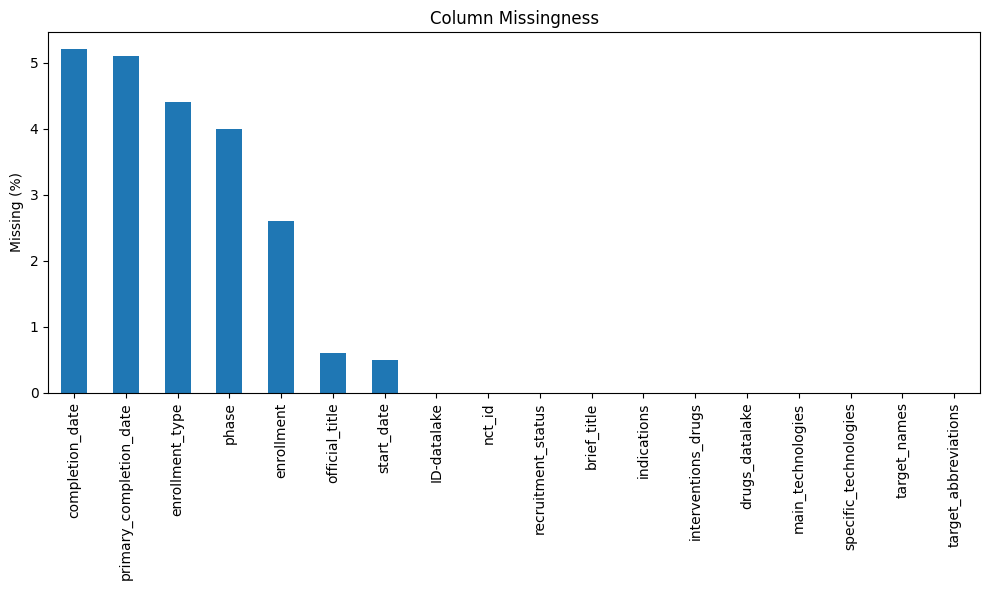

In [27]:
## Output
### Missingness chart
import matplotlib.pyplot as plt

missing_pct = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
missing_pct.plot(kind="bar")
plt.ylabel("Missing (%)")
plt.title("Column Missingness")
plt.tight_layout()

plt.savefig(
    "../outputs/figures/missingness.png",
    dpi=300
)
plt.show()

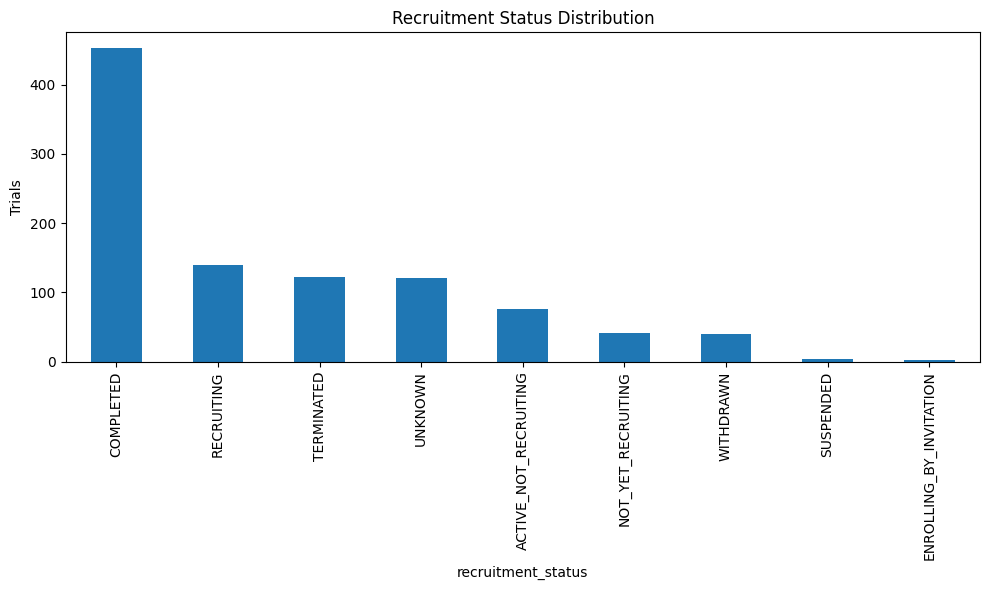

In [28]:
###status distribution chart
status_counts = (
    df["recruitment_status"]
      .value_counts()
)

plt.figure(figsize=(10,6))
status_counts.plot(kind="bar")

plt.ylabel("Trials")
plt.title("Recruitment Status Distribution")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/status_distribution.png",
    dpi=300
)

plt.show()

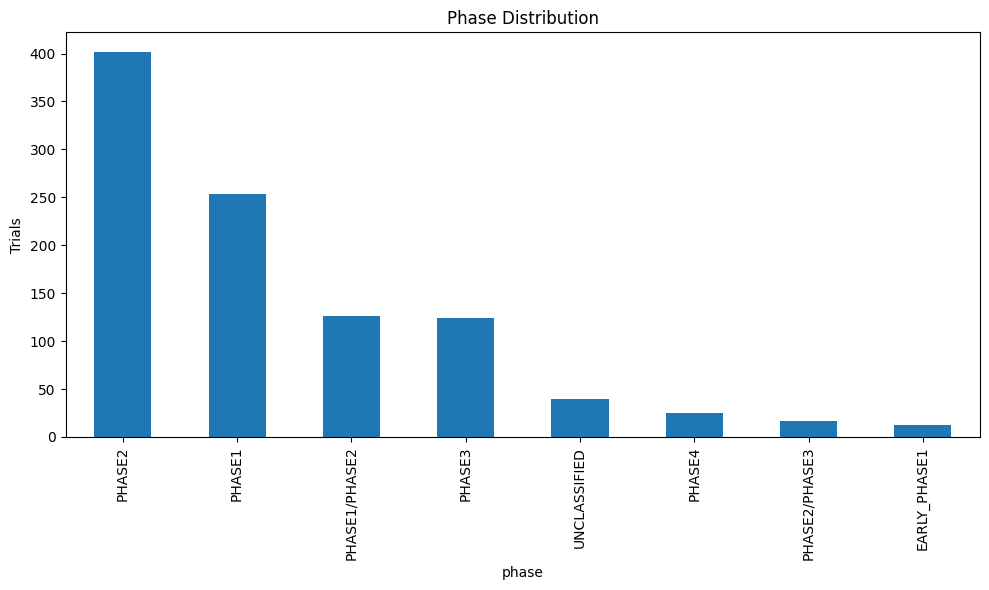

In [29]:
###phase distribution chart
phase_counts = (
    df["phase"]
      .fillna("UNCLASSIFIED")
      .value_counts()
)

plt.figure(figsize=(10,6))
phase_counts.plot(kind="bar")

plt.ylabel("Trials")
plt.title("Phase Distribution")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/phase_distribution.png",
    dpi=300
)

plt.show()